In [1]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import diffrax
import matplotlib.pyplot as plt
import matplotlib as mpl
import met_brewer as mb
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MM_nonessential_all_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True

Set up: Models, data, etc.

In [3]:
sampler = "Pathfinder"

plot_color = '#175449'

model = "MM_nonessential_all"
model_info_file = '../models/MM_nonessential_all.json'

data_dir = '../../../results/param_est/kinase_KO/std_dcr/'      
save_dir_base = '../../../results/predictions/frequency/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]


# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values()) # this is what we can modify to change the stimulus strength
k_gly_idx = list(metab_params["metab_params_basal"].keys()).index("kGly")
k_hydro_idx = list(metab_params["metab_params_basal"].keys()).index("kHydro")


# idata
idata_cyto = az.from_netcdf(data_dir + model + '_cyto_mcmc_samples_' + sampler + '.nc')

# load data to get simulation time
_, _, times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                        to_seconds=True, constant_std=False)

rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

ca_index = list(model_info["init_conds"].keys()).index("Ca")
total_AMPKAR = model_info["init_conds"]["AMPKAR"]

MM_non_all = eval(model + '(' + ','.join(str(elm) for elm in basal_params) \
            + ')')
rhs = dfrx.ODETerm(MM_non_all.prescribe_Ca_ATP_flux)

width= 1.5
height= 1.25

Write a function to run all simulations and return the results. It takes the desired 
stimuli as the inputs

In [4]:
# func to compute time to half max
# calculate time to half max of pAMPKAR_stressed/AMPKAR_stressed

def square_pulse_train(t, freq, magnitude, duration, start_time=0, stop_time=None):
    """
    Generate a train of square pulses using jax.numpy, with an optional stop time.

    Parameters
    ----------
    t : float or array-like
        Time or time vector.
    freq : float
        Frequency of pulses in Hz.
    magnitude : float
        Amplitude of each pulse.
    duration : float
        Duration of each pulse (seconds).
    start_time : float
        Time to start the first pulse.
    stop_time : float or None
        Time after which no more pulses are generated. If None, pulses continue indefinitely.

    Returns
    -------
    pulse : float or jnp.ndarray
        Pulse train value(s) at t.
    """
    t = jnp.asarray(t)
    period = 1.0 / freq
    t_shifted = t - start_time
    in_pulse = (t_shifted >= 0) & (jnp.mod(t_shifted, period) < duration)
    if stop_time is not None:
        in_pulse = in_pulse & (t < stop_time)
    return magnitude * in_pulse

def dynamic_stim(params, rhs, y0, times, Ca_func, kHydro_func, Ca_basal, kHydro_basal,
        tmax_init=1e3, rtol=1e-6, atol=1e-6, pcoeff=0.3, 
        icoeff=0.4, dcoeff=0.0, dt0=1e-10, solver = dfrx.Kvaerno5()):
    """ Function to solve the ODE with dynamic stimuli. The time-dependent RHS func expercts functions for the Ca2+ concentration and kHydro rate as the final two params in the params list (calcium first, then kHydro)."""
    
    # solver details
    stepsize_controller=dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)
    t0 = 0.0
    t1 = times[-1]
    saveat=dfrx.SaveAt(ts=times)
    # max_steps=int(3)

    # first equilibrate the system with basal conditions
    ca_basal_func = lambda t: Ca_basal
    kHydro_basal_func = lambda t: kHydro_basal

    basal_params = list(params.copy())
    basal_params.append(ca_basal_func)
    basal_params.append(kHydro_basal_func)

    sol = dfrx.diffeqsolve(
        rhs, solver, 
        t0, tmax_init, dt0, 
        y0, 
        args=basal_params,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        throw=True)
    
    # now apply the dynamic stimuli
    stim_params = list(params.copy())
    stim_params.append(Ca_func)
    stim_params.append(kHydro_func)

    # run the simulation
    sol_stressed = dfrx.diffeqsolve(
        rhs, solver, 
        t0, t1, dt0, 
        sol.ys, # use basal SS at IC
        args=stim_params, 
        saveat=saveat,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        max_steps=None,
        throw=False)
    
    return jnp.squeeze(jnp.array(sol_stressed.ys))

def compute_pAMPK_activity(sol, param, pampk_idxs=np.array([10, 15, 16]), amp_pampk_idx=14):
    return sol[pampk_idxs, :].sum(axis=0)*param[12] + sol[amp_pampk_idx, :]*param[12]*param[24]

def plot_barplot(data_df, x_name, y_name, x_label, y_label, fig_width, fig_height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0):
    fig, ax = get_sized_fig_ax(fig_width, fig_height)

    sns.barplot(data=data_df, x=x_name, y=y_name, 
            color=plot_color, ax=ax, edgecolor='black', alpha=0.75,
            errorbar='sd',err_kws={'color': 'black'})
    if invert_x:
        ax.invert_xaxis()
    
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)

    if xticklabs is not None:
        ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
    else:
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
    
    ax.tick_params(axis='both', which='major', labelsize=8)


    return fig, ax

### Single step function of increase Ca2+ and ATP fluxes from baseline to something similar to the exercise model preds

We will start by simulating for one minute

#### Ca2+ flux
Base is zero in the exercise model
Maximum is near 5e4 uM/s

#### ATP Flux
Baseline ATP flux at IC is 1.23 mM/s
Values from exercise model are on the order of 2-2.25e3 uM/s with baselines near 5e2 uM/s

#### Levels to simulate
1. Baseline
2. 100 uM/s Ca2+ flux, 0.1 mM/s ATP flux
3. 500 uM/s Ca2+ flux, 0.5 mM/s ATP flux
4. 1000 uM/s Ca2+ flux, 1.0 mM/s ATP flux
5. 2000 uM/s Ca2+ flux, 2.0 mM/s ATP flux
6. 5000 uM/s Ca2+ flux, 5.0 mM/s ATP flux

#### Timing
begin with a 5 second (0.2 Hz) step function

In [5]:
nsamples=2
params = get_param_subsample(param_names, idata_cyto, nsamples) # one param for now, then draw a random subset

Now define time-dependent functions for the Ca2+ and ATP fluxes

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/2664752549.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'Ca_stim_10hz.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/2664752549.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'Ca_stim_40hz.pdf', bbox_inches='tight', transparent=True)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.

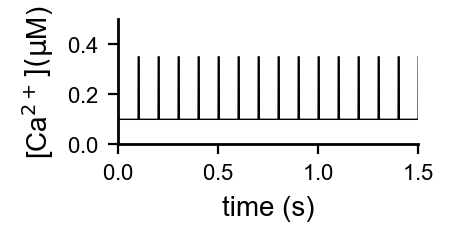

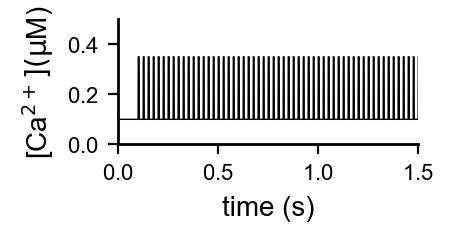

In [6]:
tsim = np.linspace(0, 10, 15000)

Ca_level = 0.25
ATP_flux_level = 2.0
duration = 5/1000 # 5ms pulses
Ca_force = lambda t, freq: 0.1 + square_pulse_train(t, freq, Ca_level, duration, start_time=0.1, stop_time=10)
kHydro = lambda t, freq: square_pulse_train(t, freq, ATP_flux_level, duration, start_time=0.1, stop_time=10)
                                
# kHydro = lambda t, stim_level: step_signal(t, 5, 0.0, stim_level, reverse=True,
#                                             reverse_time=10)

# fig, ax = get_sized_fig_ax(width/2.5, height/2.5)
fig, ax = get_sized_fig_ax(width, 0.5*height)
ax.plot(tsim, Ca_force(tsim, 10), color='k', label='Ca2+ flux',
    linewidth=0.5)
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 0.5)
ax.set_yticks([0.0, 0.2, 0.4])
# ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
ax.set_ylabel(r'[Ca$^{2+}] (\mu$M)', fontsize=10)
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
# ax.axvspan(5, 15, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_stim_10hz.pdf', bbox_inches='tight', transparent=True)

# fig, ax = get_sized_fig_ax(width/2.5, height/2.5)
fig, ax = get_sized_fig_ax(width, 0.5*height)
ax.plot(tsim, Ca_force(tsim, 40), color='k', label='Ca2+ flux',
    linewidth=0.5)
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 0.5)
ax.set_yticks([0.0, 0.2, 0.4])
# ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
ax.set_ylabel(r'[Ca$^{2+}] (\mu$M)', fontsize=10)
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
# ax.axvspan(5, 15, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_stim_40hz.pdf', bbox_inches='tight', transparent=True)

# fig, ax = get_sized_fig_ax(width/2.5, height/2.5)
# ax.plot(tsim, kHydro(tsim, 60), color=plot_color, label='Ca2+ flux',
#     linewidth=0.5)
# ax.set_xlim(0, 10)
# # ax.set_ylim(0, 1.5)
# ax.set_yticks([0])
# # ax.set_xticks([0, 20, 40])
# ax.set_ylabel('ATP flux\n(mM/s)', fontsize=10)
# ax.set_xlabel('time (s)', fontsize=10)
# ax.tick_params(axis='both', which='major', labelsize=8)
# # ax.axvspan(5, 15, color='lightblue', alpha=0.9, zorder=0)

# fig.savefig(save_dir + 'kHydro_flux.pdf', bbox_inches='tight', transparent=True)


In [7]:
tsim = np.linspace(0, 10, 15000) # 10 sec

@jax.jit
def compute_pAMPK_act_AUC(frequency, param, ca_level, atp_flux_level):

    duration = 5/1000

    # 5ms pulses
    Ca_force = lambda t, freq: 0.1 + square_pulse_train(t, freq, ca_level, duration, start_time=0.1, stop_time=10)
    kHydro = lambda t, freq: square_pulse_train(t, freq, atp_flux_level, duration, start_time=0.1, stop_time=10)

    Ca_stim = lambda t: Ca_force(t, frequency)    
    kHydro_stim = lambda t: kHydro(t, frequency)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, tsim, Ca_stim, kHydro_stim, 0.1, 0.0,
                   atol=1e-10, rtol=1e-10)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(sol, param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=tsim)
    return pAMPK_activity_AUC, pAMPK_activity, sol

vmap_compute_pAMPK_act_AUC = jax.vmap(compute_pAMPK_act_AUC, in_axes=(None, 0, None, None))

In [8]:
levels = {
    'low':{'ca_level': 0.1, 'atp_flux_level': 0.1},
    'med':{'ca_level': 0.25, 'atp_flux_level': 1.0},
    'high':{'ca_level': 0.25, 'atp_flux_level': 2.0},
}

auc_vals_freq = {}
acts_freq = {}
sols_freq = {}

freqs = [5.0, 10.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0]

for level in levels.keys():
    aucs = {}


    for i, freq in enumerate(freqs):
        # compute the AUC
        auc, _, _ = vmap_compute_pAMPK_act_AUC(freq, params, levels[level]['ca_level'], levels[level]['atp_flux_level'])
        # auc, pAMPK_act, sol = compute_pAMPK_act_AUC(freq, params)

        aucs[freq] = auc
        
    auc_vals_freq[level] = aucs
  

Bar chart of pAMPK activity AUC vs stim size

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/2337264115.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/3686494533.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(period, fontsize=8, rotation=45, ha='right')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/3686494533.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AUC_pAMPK_activity_frequency_low.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/2337264115.py:104: UserWarning: set_ticklabels() should only be used wi

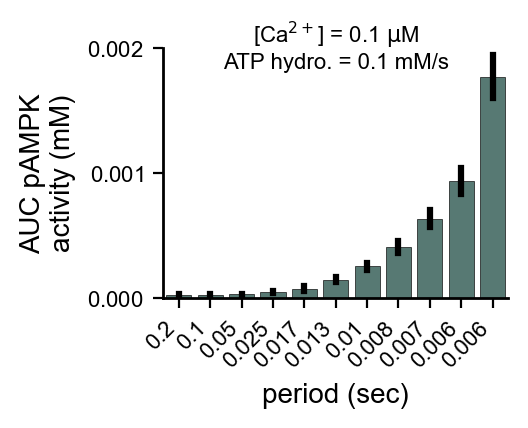

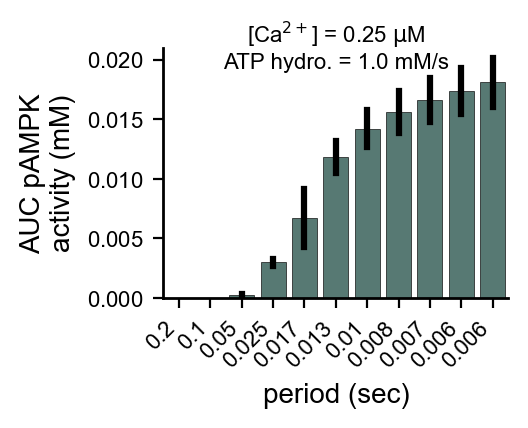

In [28]:
dat_df = pd.DataFrame(auc_vals_freq) #, columns=['AUC'])
dat_df = dat_df.reset_index().rename(columns={'index': 'frequency'})


period = [str(round(1/i, 3)) for i in freqs]

freqs = [5.0, 10.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0]
dat_df = dat_df.melt(id_vars='frequency', value_vars=['low', 'med', 'high'],
                     var_name='level', value_name='AUC')

# Expand the dataframe to have one row per replicate
dat_df = dat_df.explode('AUC').reset_index(drop=True)
dat_df['AUC'] = dat_df['AUC'].astype(float)

# only low
dat_df_low = dat_df[dat_df['level'] == 'low']

fig, ax = plot_barplot(dat_df_low, 'frequency', 'AUC', 'period (sec)', 
                       'AUC pAMPK\nactivity (mM)', 1.15*width, height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0)

xticklabs = [str(i) for i in freqs]
ax.set_ylim(0, 0.002)
ax.set_yticks([0.0, 0.001, 0.002])
ax.ticklabel_format(style='plain', axis='y')
ax.set_xticklabels(period, fontsize=8, rotation=45, ha='right')
ax.set_title(r'[Ca$^{2+}$] = 0.1 $\mu$M' + '\nATP hydro. = 0.1 mM/s', 
             fontsize=8, fontweight='regular', y=0.85)
fig.savefig(save_dir + 'AUC_pAMPK_activity_frequency_low.pdf', bbox_inches='tight', transparent=True)

# only med
dat_df_med = dat_df[dat_df['level'] == 'med']

fig, ax = plot_barplot(dat_df_med, 'frequency', 'AUC', 'period (sec)', 
                       'AUC pAMPK\nactivity (mM)', 1.15*width, height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0)

# xticklabs = [str(i) for i in freqs]
ax.set_title(r'[Ca$^{2+}$] = 0.25 $\mu$M' + '\nATP hydro. = 1.0 mM/s', 
             fontsize=8, fontweight='regular', y=0.85)
ax.set_ylim(0, 0.021)
ax.set_xticklabels(period, fontsize=8, rotation=45, ha='right')

fig.savefig(save_dir + 'AUC_pAMPK_activity_frequency_med.pdf', bbox_inches='tight', transparent=True)

### Long time sims

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/2540200972.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'Ca_stim_0.6_permin.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/2540200972.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'Ca_stim_3_permin.pdf', bbox_inches='tight', transparent=True)


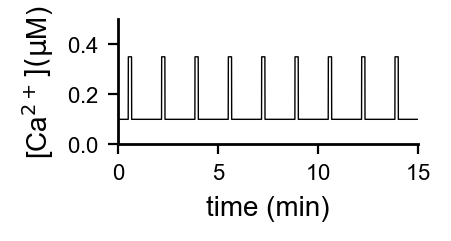

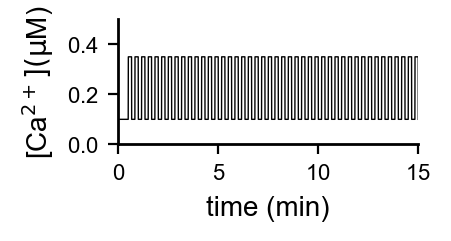

In [12]:
tsim = np.linspace(0, 1800, 18000)

Ca_level = 0.25
ATP_flux_level = 2.0
duration = 10 # 5 s pulses
Ca_force = lambda t, freq: 0.1 + square_pulse_train(t, freq, Ca_level, duration, start_time=30, stop_time=1800)
kHydro = lambda t, freq: square_pulse_train(t, freq, ATP_flux_level, duration, start_time=30, stop_time=1800)
                                
# kHydro = lambda t, stim_level: step_signal(t, 5, 0.0, stim_level, reverse=True,
#                                             reverse_time=10)

# fig, ax = get_sized_fig_ax(width/2.5, height/2.5)
fig, ax = get_sized_fig_ax(width, 0.5*height)
ax.plot(tsim/60, Ca_force(tsim, 0.6/60), color='k', label='Ca2+ flux',
    linewidth=0.5)
ax.set_xlim(0, 15)
ax.set_ylim(0, 0.5)
ax.set_yticks([0.0, 0.2, 0.4])
# ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
ax.set_ylabel(r'[Ca$^{2+}] (\mu$M)', fontsize=10)
ax.set_xlabel('time (min)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
# ax.axvspan(5, 15, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_stim_0.6_permin.pdf', bbox_inches='tight', transparent=True)

# fig, ax = get_sized_fig_ax(width/2.5, height/2.5)
fig, ax = get_sized_fig_ax(width, 0.5*height)
ax.plot(tsim/60, Ca_force(tsim, 0.05), color='k', label='Ca2+ flux',
    linewidth=0.5)
ax.set_xlim(0, 15)
ax.set_ylim(0, 0.5)
ax.set_yticks([0.0, 0.2, 0.4])
# ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
ax.set_ylabel(r'[Ca$^{2+}] (\mu$M)', fontsize=10)
ax.set_xlabel('time (min)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
# ax.axvspan(5, 15, color='lightblue', alpha=0.9, zorder=0)

fig.savefig(save_dir + 'Ca_stim_3_permin.pdf', bbox_inches='tight', transparent=True)

In [13]:
@jax.jit
def compute_pAMPK_act_AUC(frequency, param, ca_level, atp_flux_level):

    duration = 10

    # 5ms pulses
    Ca_force = lambda t, freq: 0.1 + square_pulse_train(t, freq, ca_level, duration, start_time=30, stop_time=1800)
    kHydro = lambda t, freq: square_pulse_train(t, freq, atp_flux_level, duration, start_time=30, stop_time=1800)

    Ca_stim = lambda t: Ca_force(t, frequency)    
    kHydro_stim = lambda t: kHydro(t, frequency)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, tsim, Ca_stim, kHydro_stim, 0.1, 0.0,
                   atol=1e-10, rtol=1e-10)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(sol, param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=tsim)
    return pAMPK_activity_AUC, pAMPK_activity, sol

vmap_compute_pAMPK_act_AUC = jax.vmap(compute_pAMPK_act_AUC, in_axes=(None, 0, None, None))

In [14]:
auc_vals_freq_slow = {}
acts_freq_slow = {}

freqs = [0.1/60, 0.2/60, 0.3/60, 0.4/60, 0.5/60, 0.75/60, 1/60, 2/60, 3/60]

levels = {
    'low':{'ca_level': 0.1, 'atp_flux_level': 0.1},
    'med':{'ca_level': 0.25, 'atp_flux_level': 1.0},
    'high':{'ca_level': 0.25, 'atp_flux_level': 2.0},
}

for level in levels.keys():
    aucs = {}
    acts = {}

    for i, freq in enumerate(freqs):
        # compute the AUC
        auc, act, _ = vmap_compute_pAMPK_act_AUC(freq, params, levels[level]['ca_level'], levels[level]['atp_flux_level'])
        # auc, pAMPK_act, sol = compute_pAMPK_act_AUC(freq, params)

        aucs[freq] = auc
        acts[freq] = np.max(act)
        
    auc_vals_freq_slow[level] = aucs
    acts_freq_slow[level] = acts

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/2337264115.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/130495192.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(period, fontsize=8, rotation=45, ha='right')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/130495192.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(save_dir + 'AUC_pAMPK_activity_frequency_LONG_low.pdf', bbox_inches='tight', transparent=True)
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_89021/2337264115.py:104: UserWarning: set_ticklabels() should only be used

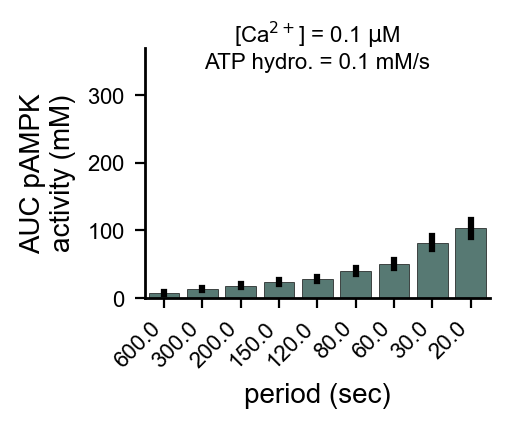

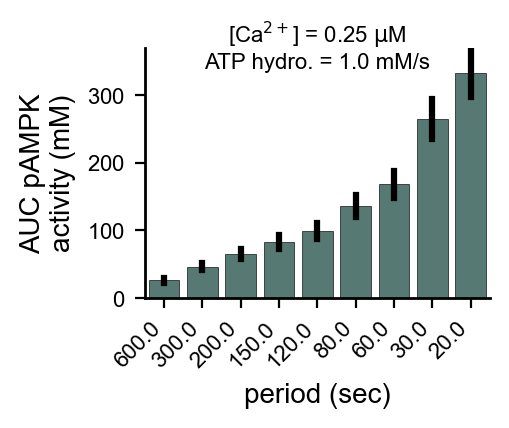

In [21]:
dat_df = pd.DataFrame(auc_vals_freq_slow) #, columns=['AUC'])
dat_df = dat_df.reset_index().rename(columns={'index': 'frequency'})

dat_df = dat_df.melt(id_vars='frequency', value_vars=['high', 'med', 'low'],
                     var_name='level', value_name='AUC')

# Expand the dataframe to have one row per replicate
dat_df = dat_df.explode('AUC').reset_index(drop=True)
dat_df['AUC'] = dat_df['AUC'].astype(float)


# only low
dat_df_low = dat_df[dat_df['level'] == 'low']


freqs = [0.1/60, 0.2/60, 0.3/60, 0.4/60, 0.5/60, 0.75/60, 1/60, 2/60, 3/60]

period = [str(round(1/i, 3)) for i in freqs]

fig, ax = plot_barplot(dat_df_low, 'frequency', 'AUC', 'period (sec)', 
                       'AUC pAMPK\nactivity (mM)', 1.15*width, height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0)
ax.set_ylim(0, 370)
ax.set_title(r'[Ca$^{2+}$] = 0.1 $\mu$M' + '\nATP hydro. = 0.1 mM/s', 
             fontsize=8, fontweight='regular', y=0.85)
xticklabs = [str(i*60) for i in freqs]
ax.set_xticklabels(period, fontsize=8, rotation=45, ha='right')

fig.savefig(save_dir + 'AUC_pAMPK_activity_frequency_LONG_low.pdf', bbox_inches='tight', transparent=True)

# only low
dat_df_med = dat_df[dat_df['level'] == 'med']

fig, ax = plot_barplot(dat_df_med, 'frequency', 'AUC', 'period (sec)', 
                       'AUC pAMPK\nactivity (mM)', 1.15*width, height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0)

xticklabs = [str(i*60) for i in freqs]
ax.set_ylim(0, 370)
ax.set_xticklabels(period, fontsize=8, rotation=45, ha='right')
ax.set_title(r'[Ca$^{2+}$] = 0.25 $\mu$M' + '\nATP hydro. = 1.0 mM/s', 
             fontsize=8, fontweight='regular', y=0.85)

fig.savefig(save_dir + 'AUC_pAMPK_activity_frequency_LONG_med.pdf', bbox_inches='tight', transparent=True)

